In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
n_points = 1000

time = np.linspace(0, 100, n_points)

# Sine wave + noise
amplitude = 10
frequency = 0.1
sine_wave = amplitude * np.sin(frequency * time)

noise_std_dev = 2
noise = np.random.randn(n_points) * noise_std_dev

synthetic_time_series = sine_wave + noise

print("Generated synthetic time series data (first 10 points):\n", synthetic_time_series[:10])

Generated synthetic time series data (first 10 points):
 [ 2.53155336  0.80586319  2.71579676 -1.00139343  0.18589133 -1.21528724
  1.8587002   2.48248057  4.16352078  3.1315906 ]


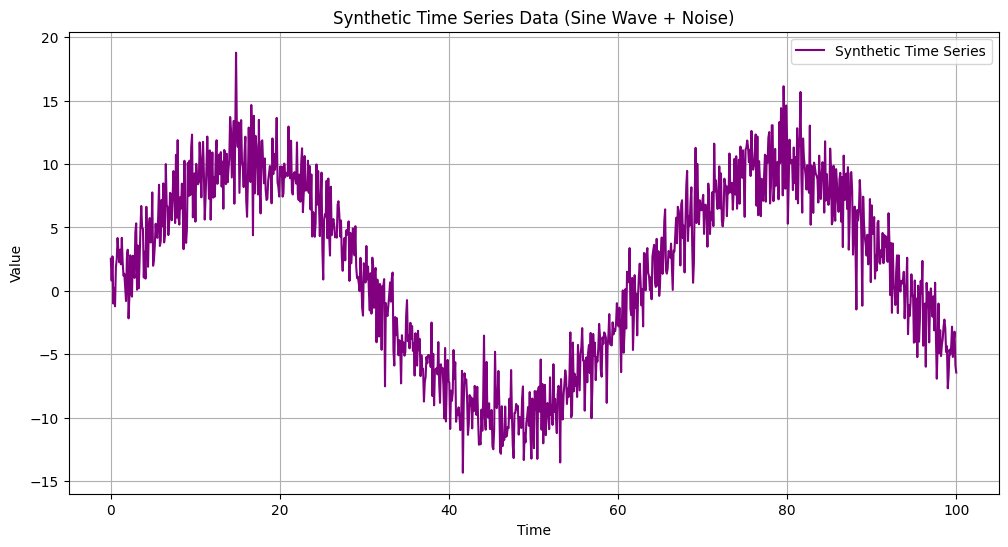

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(time, synthetic_time_series, label='Synthetic Time Series', color='purple')
plt.title('Synthetic Time Series Data (Sine Wave + Noise)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
look_back = 20
forecase_num = 3
X = []
y = []



#Create input-output pairs
for i in range(len(synthetic_time_series) - look_back - forecase_num + 1):
    feature_sequence = synthetic_time_series[i:(i + look_back)]
    target_value = synthetic_time_series[i + look_back:i + look_back + forecase_num]
    X.append(feature_sequence)
    y.append(target_value)

X = np.array(X)
y = np.array(y)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")
print("First 5 input sequences:\n", X[:5])
print("First 5 target values:\n", y[:5])

Shape of X (input sequences): (978, 20)
Shape of y (target values): (978, 3)
First 5 input sequences:
 [[ 2.53155336  0.80586319  2.71579676 -1.00139343  0.18589133 -1.21528724
   1.8587002   2.48248057  4.16352078  3.1315906   2.25292808  3.243779
   2.09177866  4.17847223  2.29336986  1.19743202  1.34901348  0.33523006
  -0.8049405   2.62930812]
 [ 0.80586319  2.71579676 -1.00139343  0.18589133 -1.21528724  1.8587002
   2.48248057  4.16352078  3.1315906   2.25292808  3.243779    2.09177866
   4.17847223  2.29336986  1.19743202  1.34901348  0.33523006 -0.8049405
   2.62930812  3.23968612]
 [ 2.71579676 -1.00139343  0.18589133 -1.21528724  1.8587002   2.48248057
   4.16352078  3.1315906   2.25292808  3.243779    2.09177866  4.17847223
   2.29336986  1.19743202  1.34901348  0.33523006 -0.8049405   2.62930812
   3.23968612 -2.16729657]
 [-1.00139343  0.18589133 -1.21528724  1.8587002   2.48248057  4.16352078
   3.1315906   2.25292808  3.243779    2.09177866  4.17847223  2.29336986
   1.1

In [5]:
#Convert NumPy arrays to PyTorch tensors and reshape X
#Ensure X has shape (batch_size, sequence_length, input_size)
#For univariate time series, input_size is 1
X_tensor = torch.from_numpy(X).float().unsqueeze(-1)
y_tensor = torch.from_numpy(y).float()

print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")

#Split data into training and testing sets
train_size = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size

        #Define the rNN layer and a linear layer
        #batch_first=True means input/output tensors are (batch_size, seq_len, features)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    # 5. Define the forward pass
    def forward(self, x):
        #Initialize hidden state with zeros
        #(num_layers * num_directions, batch_size, hidden_size)
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        #Forward propagate RNN
        out, _ = self.rnn(x, h0)

        #Pass the output of the last time step to the linear layer
        #out[:, -1, :] takes the hidden state of the last time step
        out = self.fc(out[:, -1, :])

        #Another option
        #out, hnn = self.rnn(x)
        #logits = self.fc(hn[-1])
        return out

print("RNNModel class defined successfully.")

Shape of X_tensor: torch.Size([978, 20, 1])
Shape of y_tensor: torch.Size([978, 3])
Shape of X_train: torch.Size([782, 20, 1])
Shape of y_train: torch.Size([782, 3])
Shape of X_test: torch.Size([196, 20, 1])
Shape of y_test: torch.Size([196, 3])
RNNModel class defined successfully.


In [6]:
#Instantiate the RNNModel
input_size = 1
hidden_size = 50
output_size = 3
train_losses = []
#Define number of training epochs
num_epochs = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNModel(input_size, hidden_size, output_size).to(device)

#Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error Loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001


#Move data to the same device as the model
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

#Create a training loop
print("Starting RNN model training...")
for epoch in range(num_epochs):
    #Forward pass
    model.train() #Set model to train mode
    outputs = model(X_train)

    #Reshape outputs to match y_train shape if necessary
    #outputs.squeeze() handles cases where output is (batch_size, 1) and y_train is (batch_size)
    loss = criterion(outputs.squeeze(), y_train)

    #Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    #Print loss every few epochs
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("RNN model training complete.")

Starting RNN model training...
Epoch [10/1000], Loss: 48.8755
Epoch [20/1000], Loss: 41.4637
Epoch [30/1000], Loss: 34.4883
Epoch [40/1000], Loss: 29.1944
Epoch [50/1000], Loss: 25.1071
Epoch [60/1000], Loss: 21.8983
Epoch [70/1000], Loss: 19.3523
Epoch [80/1000], Loss: 16.8612
Epoch [90/1000], Loss: 14.8939
Epoch [100/1000], Loss: 13.2893
Epoch [110/1000], Loss: 12.0229
Epoch [120/1000], Loss: 10.9924
Epoch [130/1000], Loss: 10.0990
Epoch [140/1000], Loss: 9.2981
Epoch [150/1000], Loss: 8.5457
Epoch [160/1000], Loss: 7.8702
Epoch [170/1000], Loss: 7.3256
Epoch [180/1000], Loss: 6.9279
Epoch [190/1000], Loss: 6.6137
Epoch [200/1000], Loss: 6.3439
Epoch [210/1000], Loss: 6.0978
Epoch [220/1000], Loss: 5.8783
Epoch [230/1000], Loss: 5.7266
Epoch [240/1000], Loss: 5.6480
Epoch [250/1000], Loss: 5.5025
Epoch [260/1000], Loss: 5.3995
Epoch [270/1000], Loss: 5.3013
Epoch [280/1000], Loss: 5.2141
Epoch [290/1000], Loss: 5.1332
Epoch [300/1000], Loss: 5.0859
Epoch [310/1000], Loss: 5.0034
Epoc

In [7]:
#Evaluate the model on the test set
model.eval() #Set the model to evaluation mode
with torch.no_grad(): #Disable gradient calculation for evaluation
    test_predictions = model(X_test)
    test_loss = criterion(test_predictions, y_test)

print(f'Test Loss: {test_loss.item():.4f}')

Test Loss: 5.1338


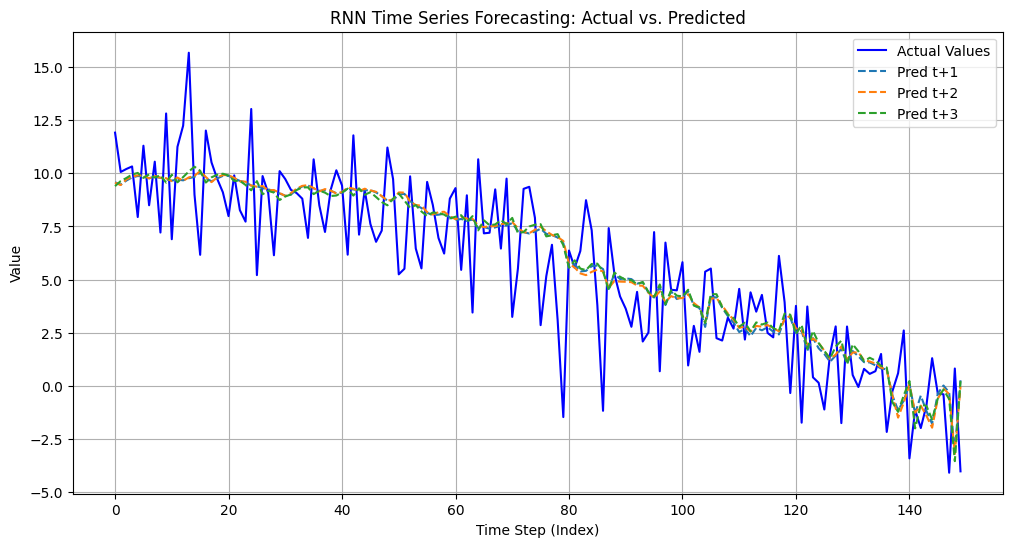

In [25]:
#Visualize predictions against actual values
#Move data back to CPU for plotting
predictions_np = test_predictions.cpu().numpy()
actual_np = y_test.cpu().numpy()

nums_to_plot = 150

#predictions_np = predictions_np[:nums_to_plot].reshape(-1)
#actual_np = actual_np[:nums_to_plot].reshape(-1)

predictions_np = predictions_np[:nums_to_plot]
actual_np = actual_np[:nums_to_plot]


plt.figure(figsize=(12, 6))
plt.plot(actual_np[:,0], label='Actual Values', color='blue')
for i in range(3):
    plt.plot(predictions_np[:, i], '--', label=f"Pred t+{i+1}")
plt.legend()
plt.title('RNN Time Series Forecasting: Actual vs. Predicted')
plt.xlabel('Time Step (Index)')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
print("\nThree test examples:\n")
for i in range(3):
    input_window = X_test[i].cpu().numpy().squeeze()
    true_values = y_test[i].cpu().numpy()
    predicted_values = test_predictions[i].cpu().numpy()

    print(f"Test Example {i+1}")
    print("Input window:")
    print(np.round(input_window, 3))
    print("True next 3 values:")
    print(np.round(true_values, 3))
    print("Predicted next 3 values:")
    print(np.round(predicted_values, 3))
    print("-" * 60)


Three test examples:

Test Example 1
Input window:
[13.054  7.069  8.116 11.188  8.28  10.047 10.167  7.213 13.299 10.075
 14.401 12.593  7.526 16.127 11.483  8.051 14.615 12.318  5.29   8.34 ]
True next 3 values:
[11.913 10.064 10.204]
Predicted next 3 values:
[9.578 9.556 9.395]
------------------------------------------------------------
Test Example 2
Input window:
[ 7.069  8.116 11.188  8.28  10.047 10.167  7.213 13.299 10.075 14.401
 12.593  7.526 16.127 11.483  8.051 14.615 12.318  5.29   8.34  11.913]
True next 3 values:
[10.064 10.204 10.323]
Predicted next 3 values:
[9.466 9.447 9.637]
------------------------------------------------------------
Test Example 3
Input window:
[ 8.116 11.188  8.28  10.047 10.167  7.213 13.299 10.075 14.401 12.593
  7.526 16.127 11.483  8.051 14.615 12.318  5.29   8.34  11.913 10.064]
True next 3 values:
[10.204 10.323  7.943]
Predicted next 3 values:
[9.658 9.714 9.779]
------------------------------------------------------------
